In [4]:
# import tensorflow as tf

# print(tf.__version__)
# print(tf.config.list_physical_devices('GPU'))
# print(tf.test.is_built_with_cuda())
# checking complete 

2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [5]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [6]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 50
CHANNELS = 3

In [7]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)


Found 2152 files belonging to 3 classes.


W0000 00:00:1778211709.903447   71501 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1778211709.903876   71501 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [8]:
class_names = dataset.class_names
class_names
len(dataset)

68

In [9]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    # print(label_batch.numpy())

(32, 256, 256, 3)


In [10]:
# Printing the first image of 32 images
for image_batch, label_batch in dataset.take(1):
    print(image_batch[31])

tf.Tensor(
[[[135. 126. 129.]
  [133. 124. 127.]
  [137. 128. 131.]
  ...
  [163. 157. 161.]
  [162. 156. 160.]
  [162. 156. 160.]]

 [[137. 128. 131.]
  [136. 127. 130.]
  [141. 132. 135.]
  ...
  [159. 153. 157.]
  [159. 153. 157.]
  [158. 152. 156.]]

 [[134. 125. 128.]
  [133. 124. 127.]
  [140. 131. 134.]
  ...
  [157. 151. 155.]
  [158. 152. 156.]
  [158. 152. 156.]]

 ...

 [[189. 184. 190.]
  [185. 180. 186.]
  [174. 169. 175.]
  ...
  [180. 179. 187.]
  [182. 181. 189.]
  [203. 202. 210.]]

 [[170. 165. 171.]
  [167. 162. 168.]
  [158. 153. 159.]
  ...
  [181. 180. 188.]
  [180. 179. 187.]
  [191. 190. 198.]]

 [[164. 159. 165.]
  [168. 163. 169.]
  [168. 163. 169.]
  ...
  [192. 191. 199.]
  [188. 187. 195.]
  [184. 183. 191.]]], shape=(256, 256, 3), dtype=float32)


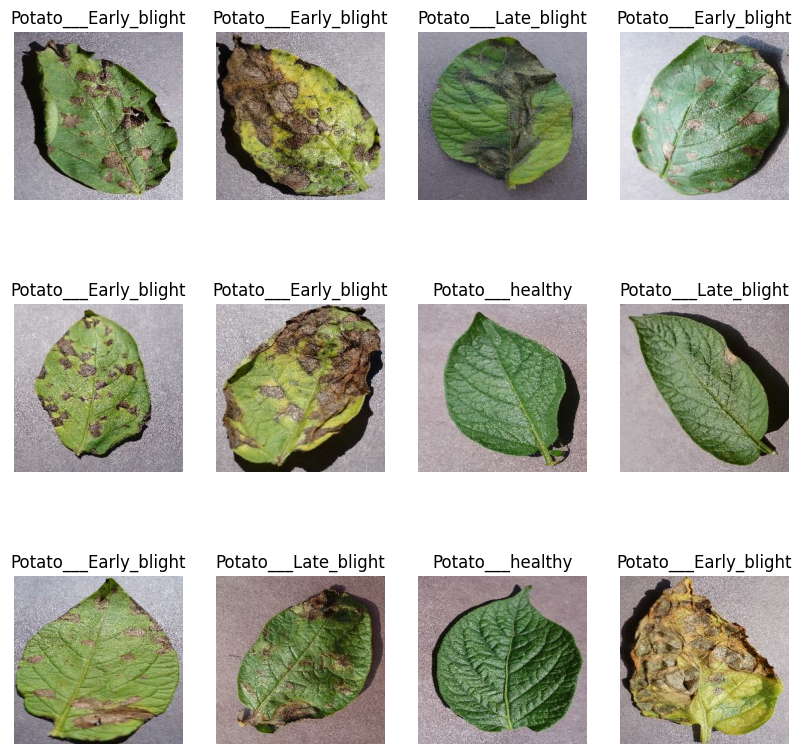

In [7]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [11]:
len(dataset)

68

In [42]:
# 80% ==> Training data
# 20% ==> 10% validation, 10% testing


In [12]:
def get_dataset_partitions_tf(ds, train_split=0.8,val_split=0.1, test_split=0.1, shuffle=True, shuffle_size = 10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds
    

In [13]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
# preprocessing pipeline
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1.0/255)
])

In [16]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])


In [17]:
print("OK")

OK


In [18]:
# Define input_shape for a single image
input_shape_single = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

n_classes = 3

model = models.Sequential([
    
    # Input Layer
    layers.Input(shape=input_shape_single),

    resize_and_rescale,
    data_augmentation,

    # CNN Layer 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # CNN Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # CNN Layer 3
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(n_classes, activation='softmax')
])

# Build model


# Model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,979 (14.28 MB)

 Trainable params: 3,742,979 (14.28 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

In [20]:
history = model.fit(train_ds, epochs=EPOCHS,batch_size = BATCH_SIZE, verbose=1,validation_data=val_ds)

Epoch 1/50


I0000 00:00:1778211780.952297   72231 cuda_dnn.cc:461] Loaded cuDNN version 92101


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6216 - loss: 0.9537

I0000 00:00:1778211798.904570   72925 shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 27 of 10000
I0000 00:00:1778211799.961656   72925 shuffle_dataset_op.cc:483] Shuffle buffer filled.
I0000 00:00:1778211799.968186   72925 shuffle_dataset_op.cc:483] Shuffle buffer filled.


54/54 ━━━━━━━━━━━━━━━━━━━━ 29s 284ms/step - accuracy: 0.7413 - loss: 0.6806 - val_accuracy: 0.7552 - val_loss: 0.5073
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.8767 - loss: 0.3292 - val_accuracy: 0.9115 - val_loss: 0.2355
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9172 - loss: 0.2287 - val_accuracy: 0.9010 - val_loss: 0.2198
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9016 - loss: 0.2527 - val_accuracy: 0.9635 - val_loss: 0.1063
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9508 - loss: 0.1419 - val_accuracy: 0.9635 - val_loss: 0.0870
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9554 - loss: 0.1135 - val_accuracy: 0.9583 - val_loss: 0.1051
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9572 - loss: 0.1110 - val_accuracy: 0.9375 - val_loss: 0.1686
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9479 - loss: 0.1391 - val_accuracy: 0.9531 - val_loss: 

In [65]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.9727 - loss: 0.0518


In [66]:
scores


[0.05182516574859619, 0.97265625]

In [67]:
history


In [68]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [69]:
acc= history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and validation Accuracy')

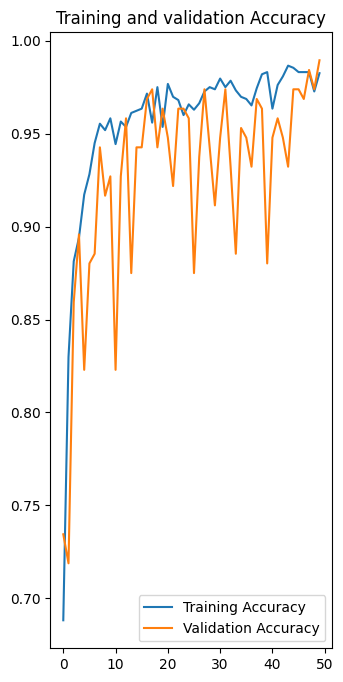

In [70]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and validation Accuracy')

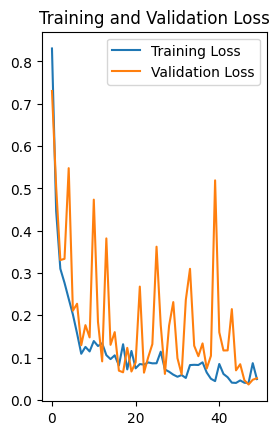

In [72]:
plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
first images's actual label: Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
[9.9999988e-01 1.5658061e-07 9.0845858e-34]
0
Predicted Label: Potato___Early_blight


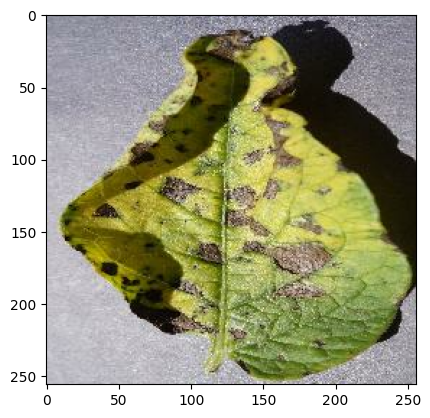

In [84]:
import numpy as np
for image_batch, labels_batch in test_ds.take(1):
    plt.imshow(image_batch[0].numpy().astype('uint8'))
    first_image =image_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    print("first image to predict")
    plt.imshow(first_image)
    print("first images's actual label:", class_names[first_label])
    batch_prediction = model.predict(image_batch)
    print(batch_prediction[0])
    print(np.argmax(batch_prediction[0]))
    print("Predicted Label:", class_names[np.argmax(batch_prediction[0])])

In [93]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array,0) # this will create a batch
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100* (np.max(predictions[0])),2)
    return predicted_class,confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


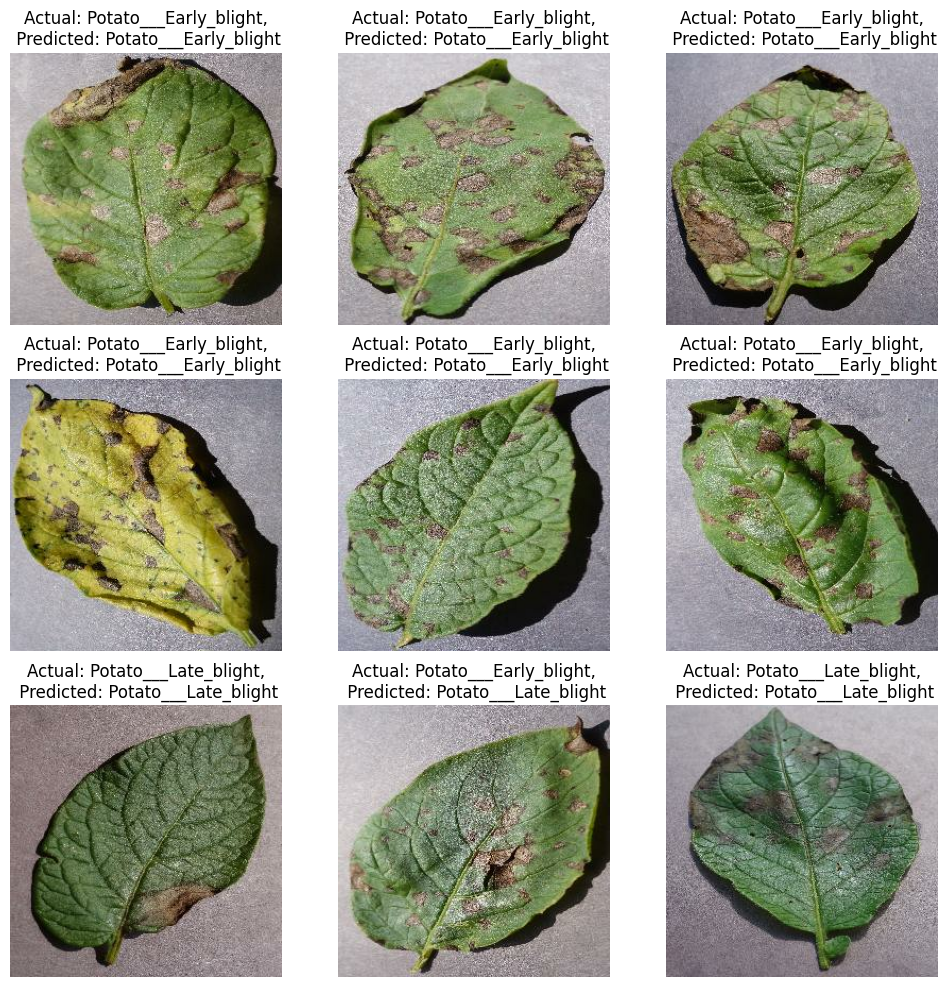

In [95]:
plt.figure(figsize=(12,12))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}")
        plt.axis("off")

In [99]:
model_version = 1
model.save(f"./models/model_v{model_version}.keras")